In [2]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots
from neuralhydrology.nh_run import start_run, eval_run

In [7]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name = 'EXP06_modeltype'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [4]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP06_modeltype_no_sw_cuda_10basin_2208_204641',
 'EXP06_modeltype_no_sw_cuda_2108_163231',
 'EXP06_modeltype_no_sw_ealstm_10basin_2208_194906',
 'EXP06_modeltype_no_sw_ealstm_2108_155730',
 'EXP06_modeltype_wi_sw_cuda_10basin_2508_092004',
 'EXP06_modeltype_wi_sw_cuda_2208_152739',
 'EXP06_modeltype_wi_sw_ealstm_10basin_2208_201730',
 'EXP06_modeltype_wi_sw_ealstm_2108_161450']

In [5]:
results_tuple_cuda = eval_wrapper.quick_eval(fp_no_sw='EXP06_modeltype_no_sw_cuda_10basin_2208_204641',
    fp_wi_sw='EXP06_modeltype_wi_sw_cuda_10basin_2508_092004',
    run_dir = all_runs_dir)
results_tuple_ealstm = eval_wrapper.quick_eval(fp_no_sw='EXP06_modeltype_no_sw_ealstm_10basin_2208_194906',
    fp_wi_sw='EXP06_modeltype_wi_sw_ealstm_10basin_2208_201730',
    run_dir = all_runs_dir)
basin_IDs = list(results_tuple_cuda[0].keys())

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_wi_sw_cuda_10basin_2508_092004
# Validation: 100%|██████████| 10/10 [00:01<00:00,  6.32it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_wi_sw_cuda_10basin_2508_092004
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_no_sw_cuda_10basin_2208_204641
# Validation: 100%|██████████| 10/10 [00:01<00:00,  7.01it/s]
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP06_modeltype_no_sw_cuda_10basin_2208_204641
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152050', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600'

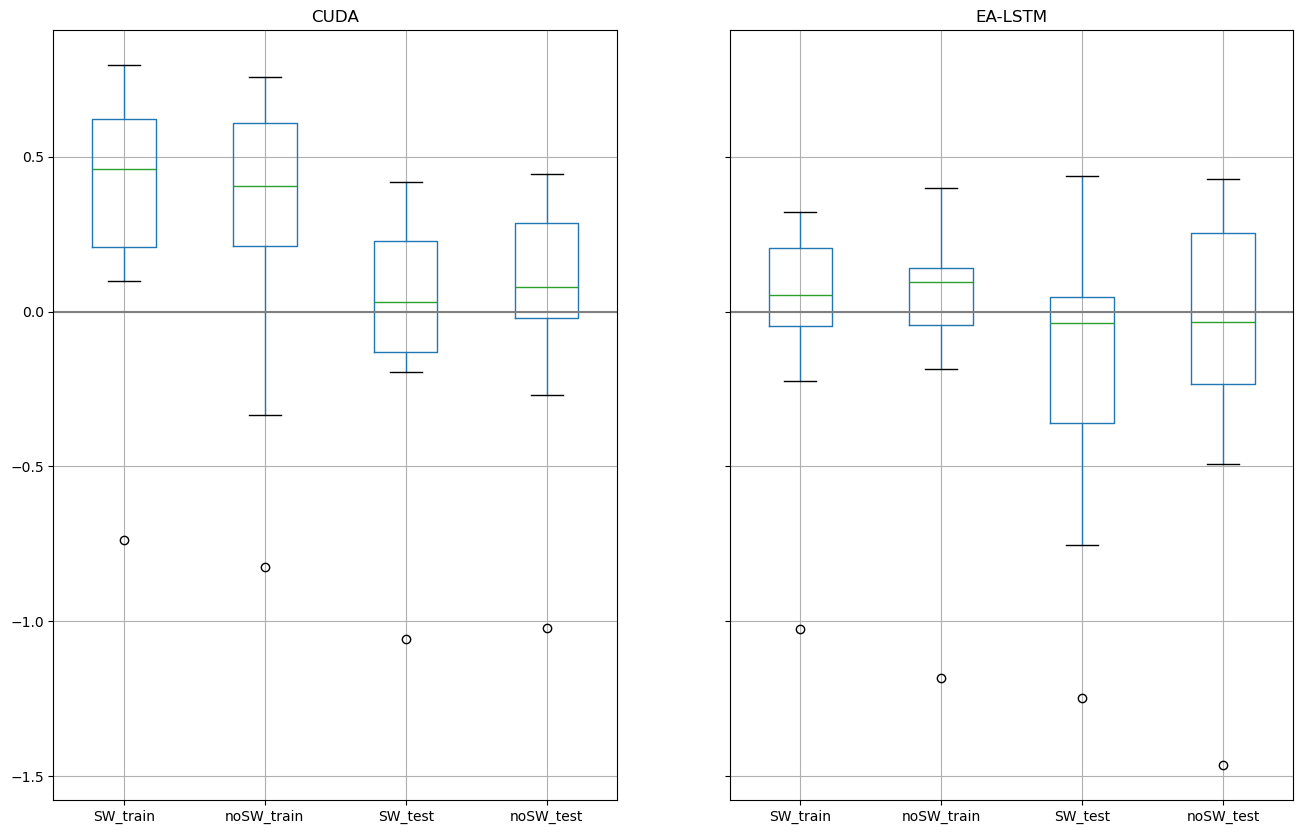

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10),sharey=True)
cuda_nse_df = comp_plots.boxplot_from_tuple(results_tuple_cuda,ax=axs[0],tuple_names=default_order,exp_name = 'CUDA')
ealstm_nse_df = comp_plots.boxplot_from_tuple(results_tuple_ealstm,ax=axs[1],tuple_names=default_order,exp_name = 'EA-LSTM')
# axs[0].set_ylim([-1.5,1])

In [11]:
cuda_nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152050,5101500,5608096
SW_train,0.795688,-0.738911,0.142124,0.407781,0.550871,0.645288,0.490192,0.100336,0.432270,0.750005
noSW_train,0.758322,-0.826070,0.176493,0.353896,0.630414,0.696936,0.454438,-0.333209,0.323271,0.549906
SW_test,-0.127111,-1.056306,-0.131550,0.052214,0.254224,0.417805,0.143588,-0.195124,0.011111,0.286303
noSW_test,0.291152,-1.022478,-0.038032,0.029162,0.081634,0.442692,0.320016,-0.270673,0.074030,0.275150


In [10]:
ealstm_nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152050,5101500,5608096
SW_train,-0.003123,-1.025020,-0.224593,0.235890,-0.063055,0.321087,0.114417,0.018798,0.091262,0.312342
noSW_train,0.100349,-1.183945,-0.185192,0.266193,0.037759,0.397869,0.112238,-0.070411,0.087722,0.149159
SW_test,-0.753959,-1.247522,-0.403261,0.003583,-0.077399,0.029914,0.438652,-0.225722,0.054820,0.099664
noSW_test,-0.493321,-1.464190,-0.254905,-0.176275,0.111397,0.319725,0.429662,-0.051850,-0.018173,0.301193


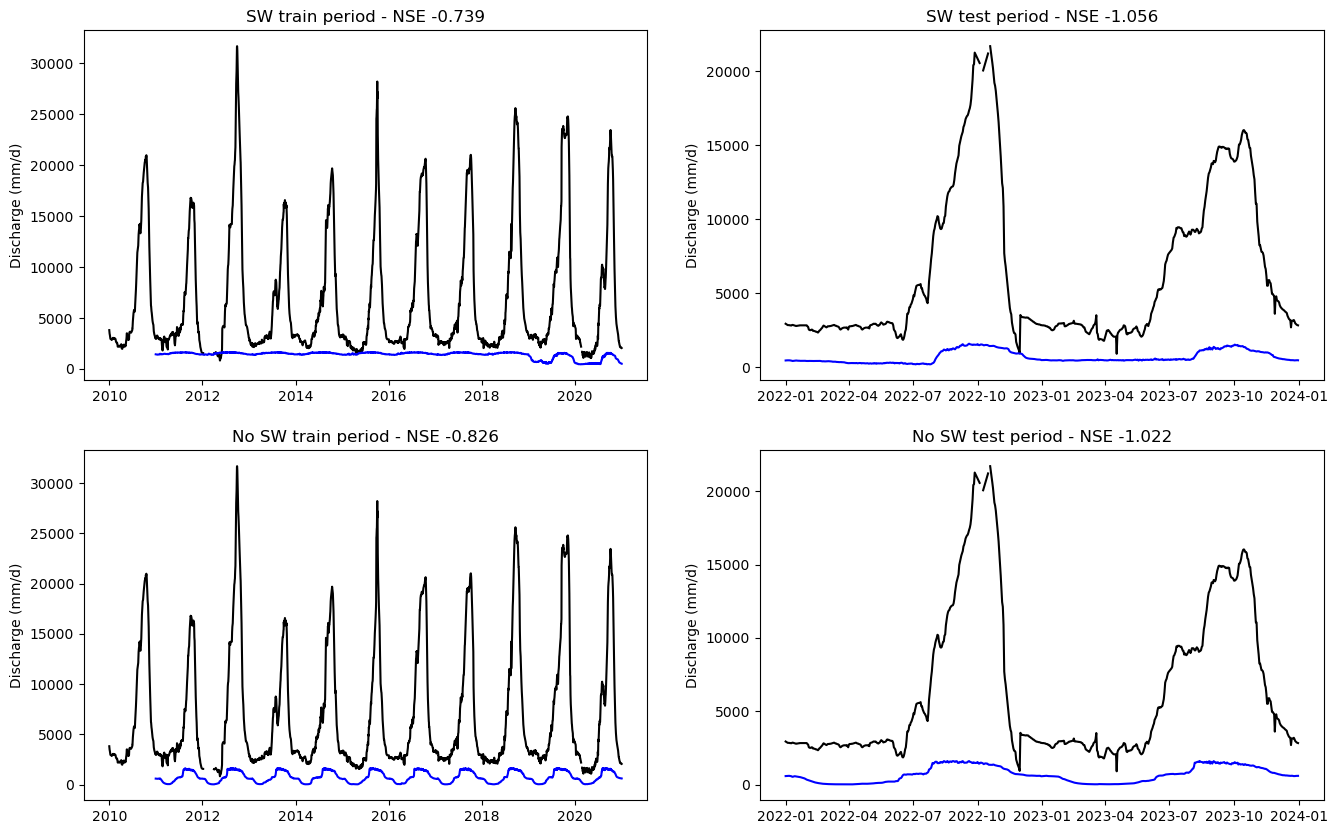

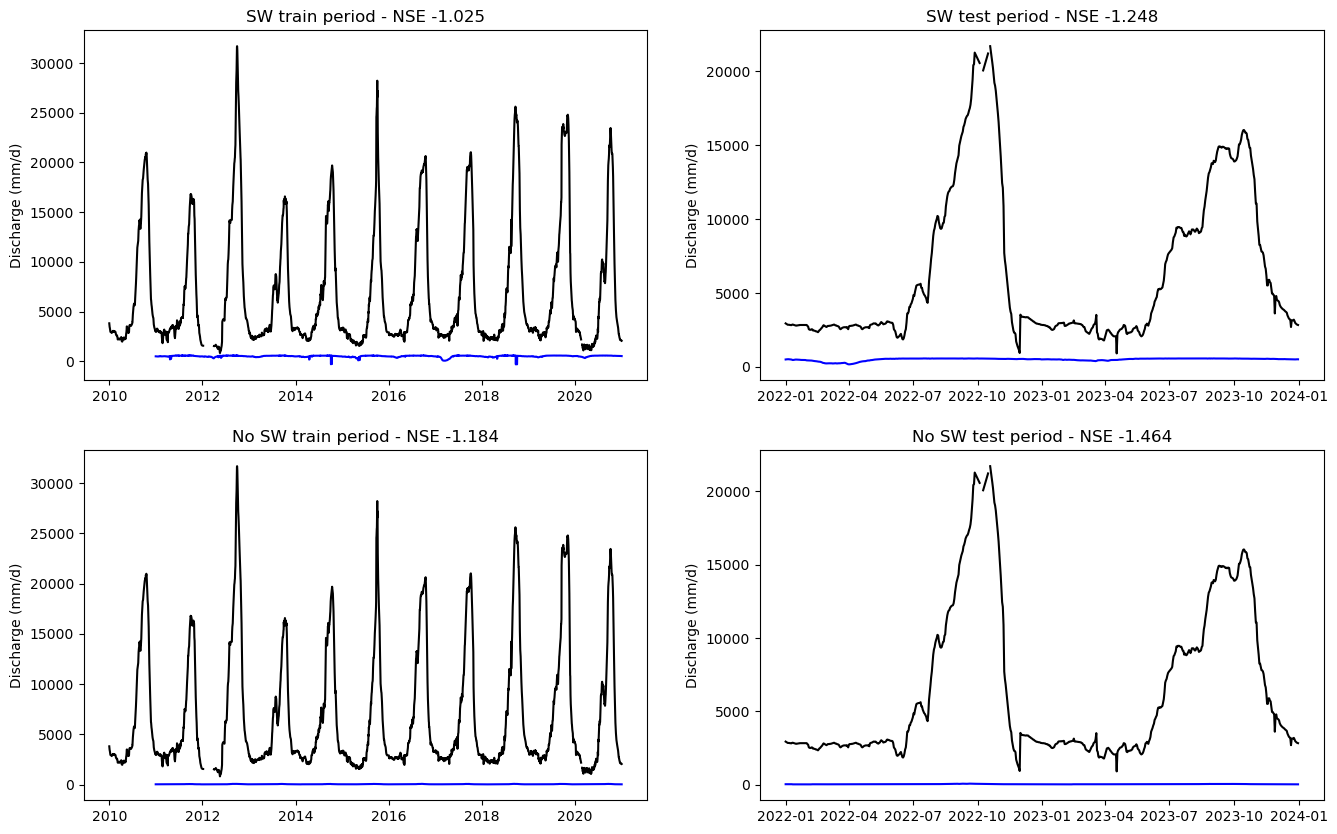

In [13]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = "1834101");
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key ="1834101");

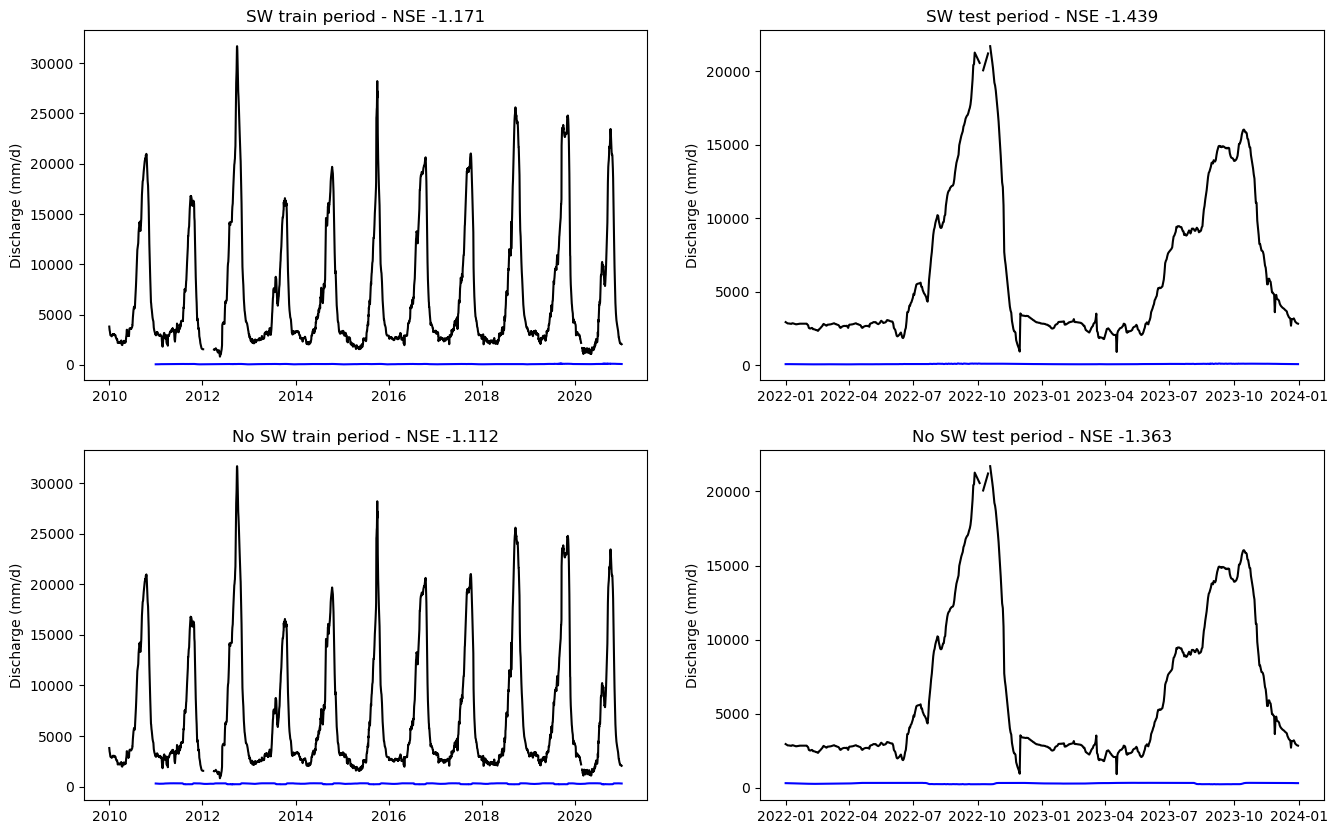

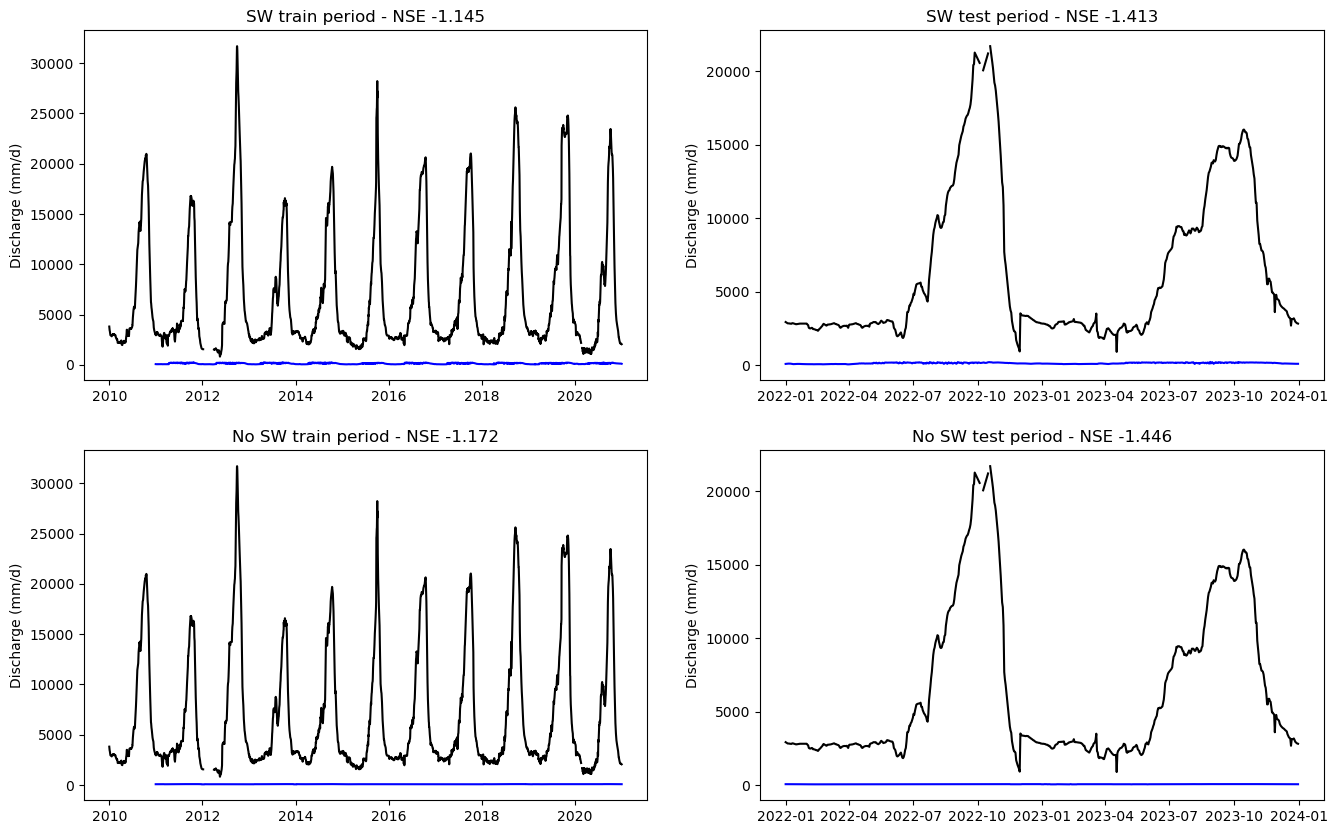

In [6]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[1]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[1]);

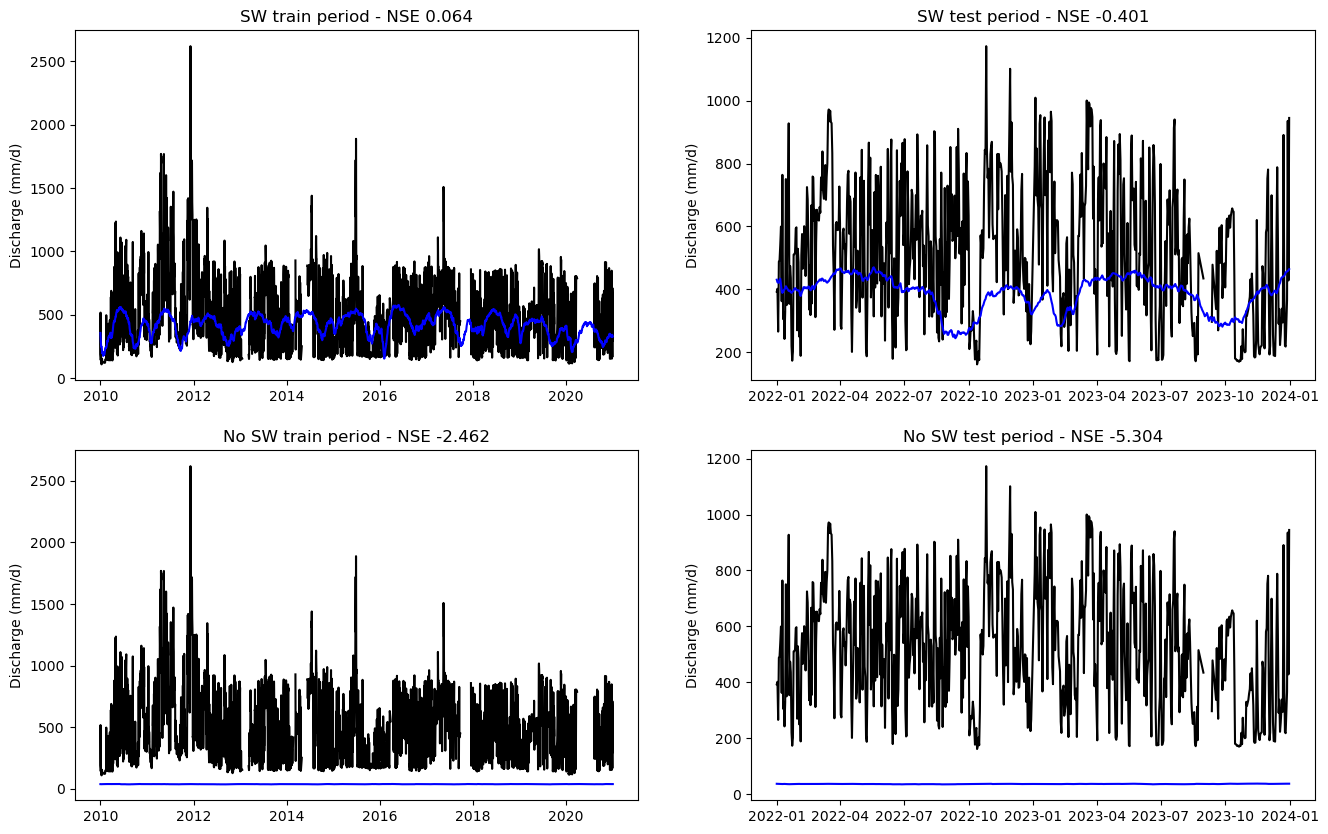

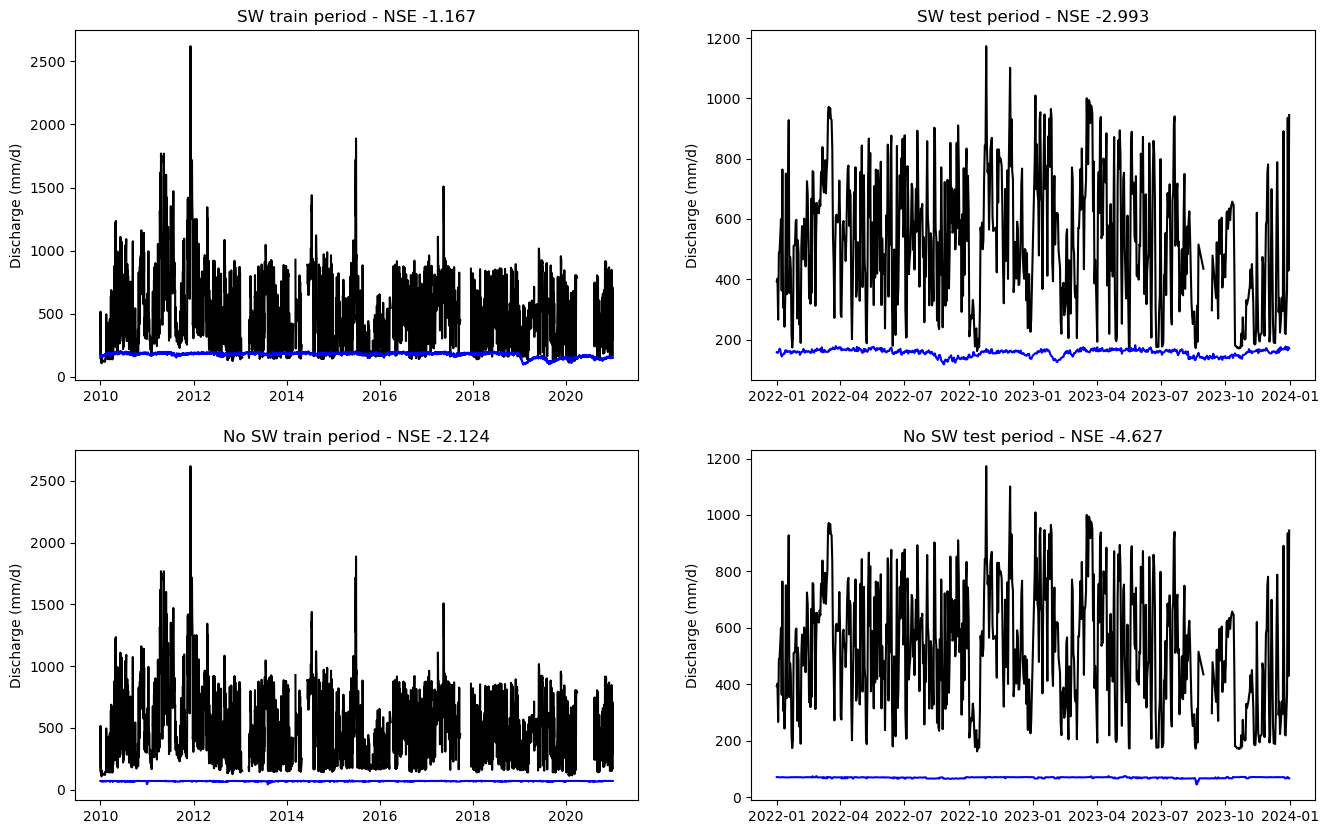

In [9]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[2]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[2]);

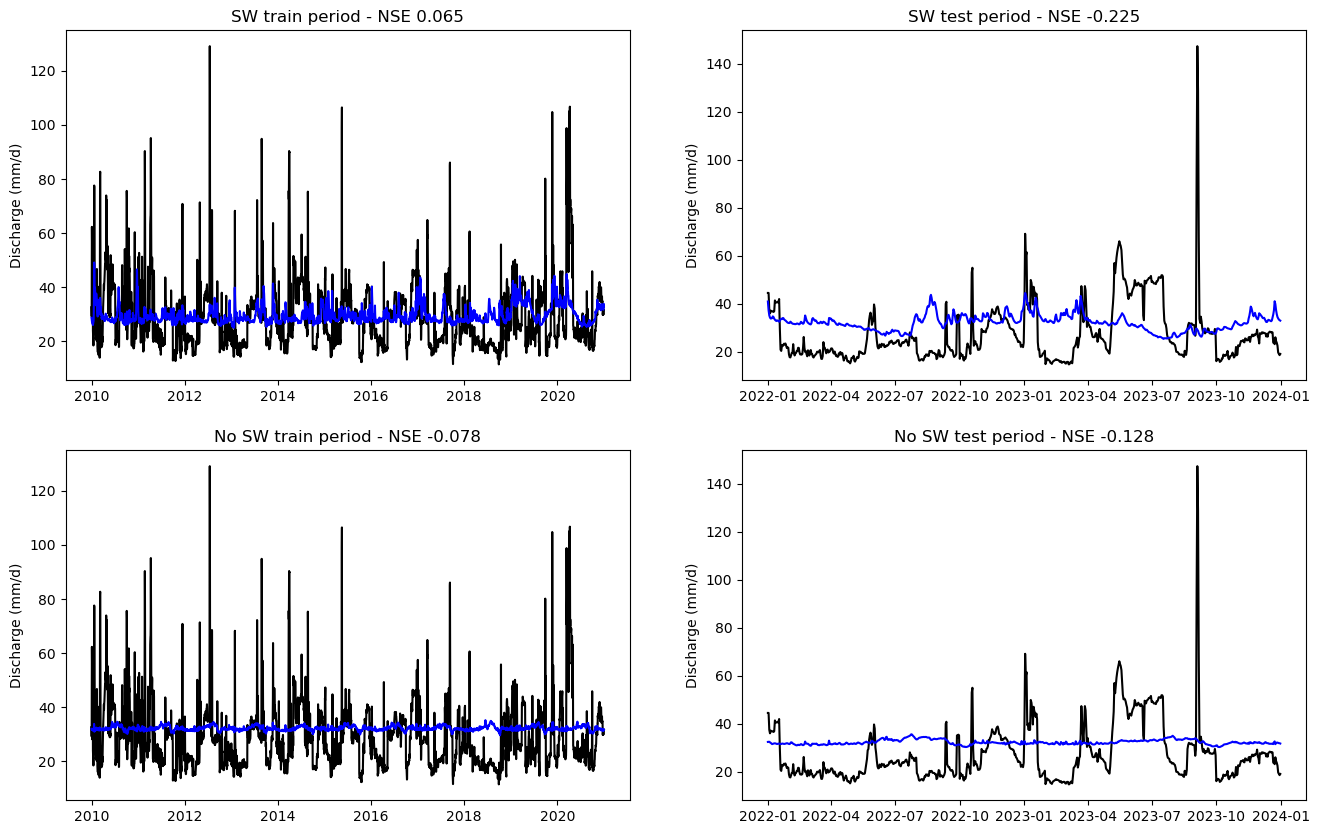

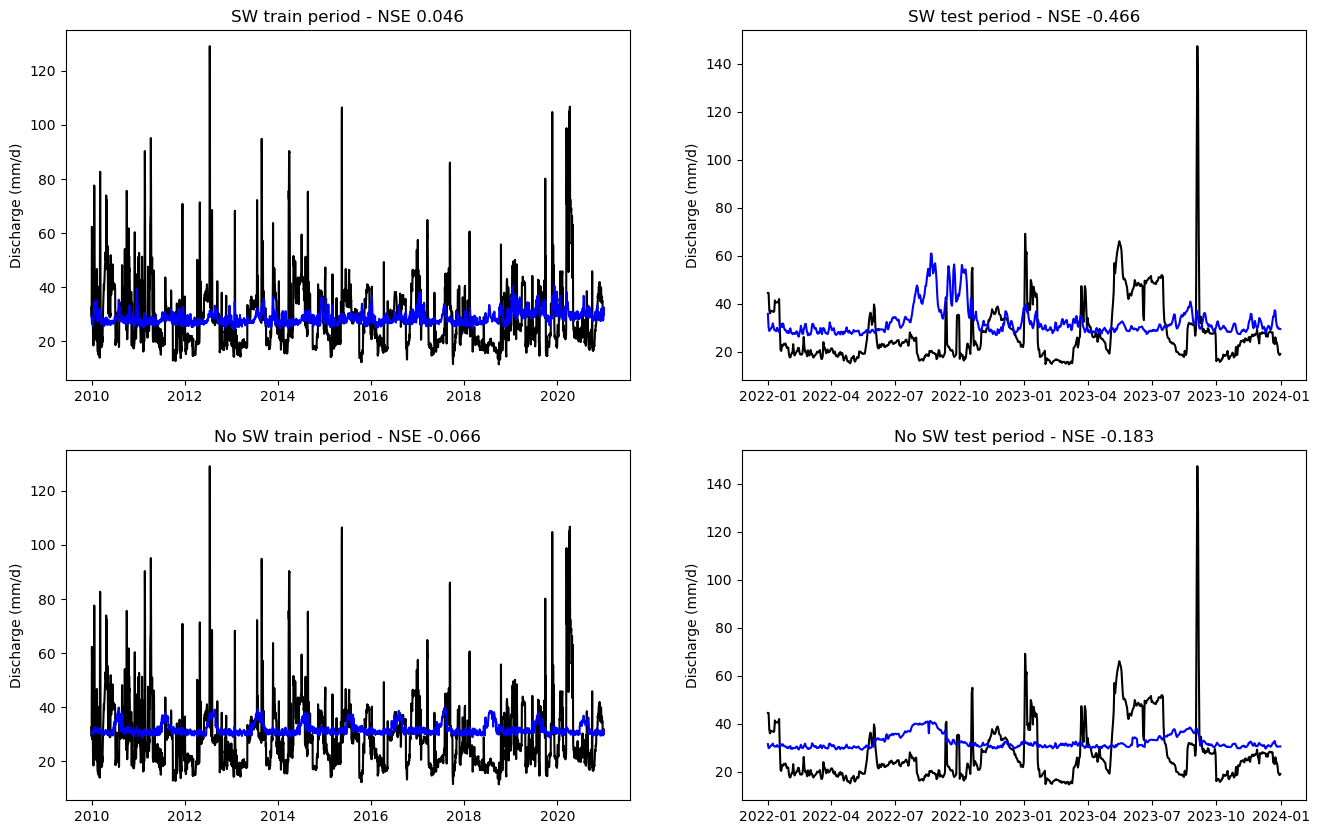

In [10]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[3]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[3]);

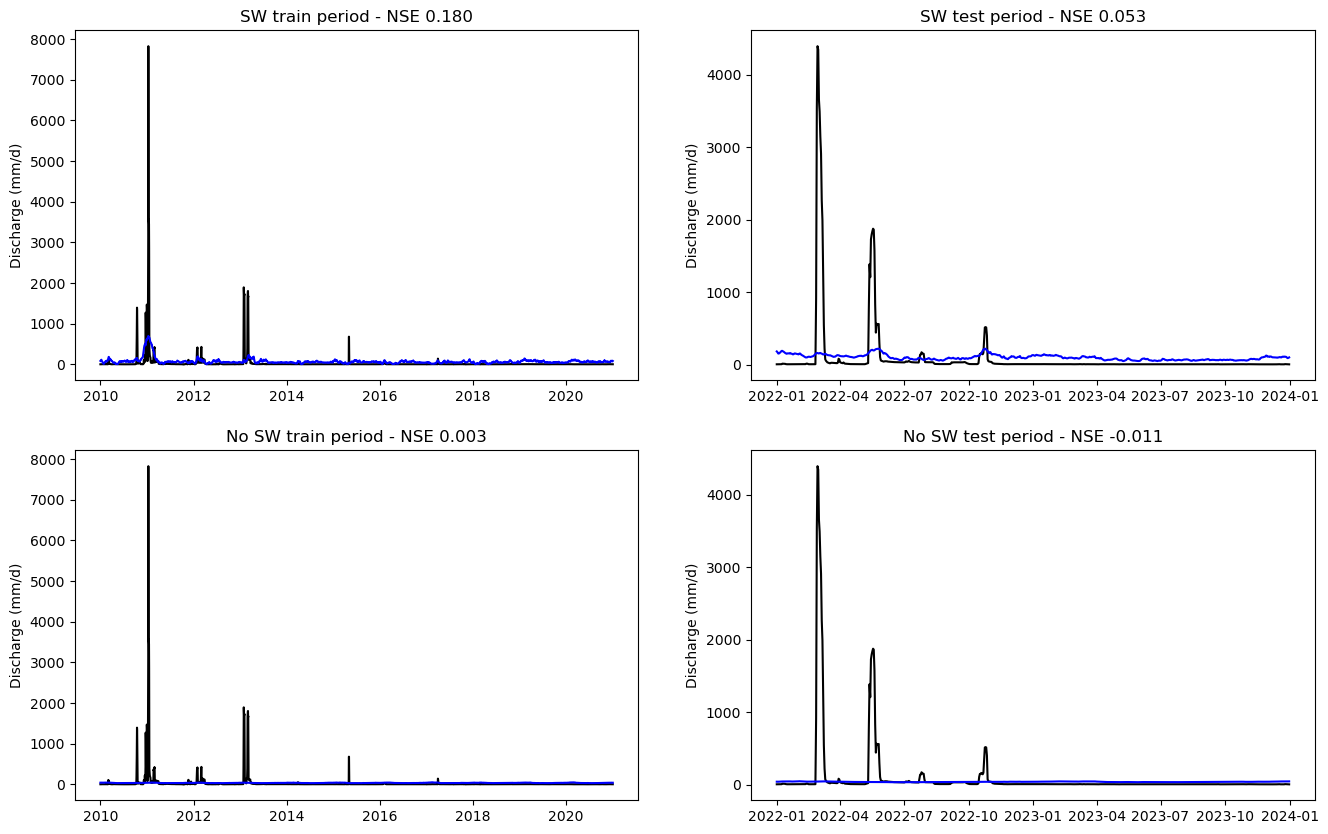

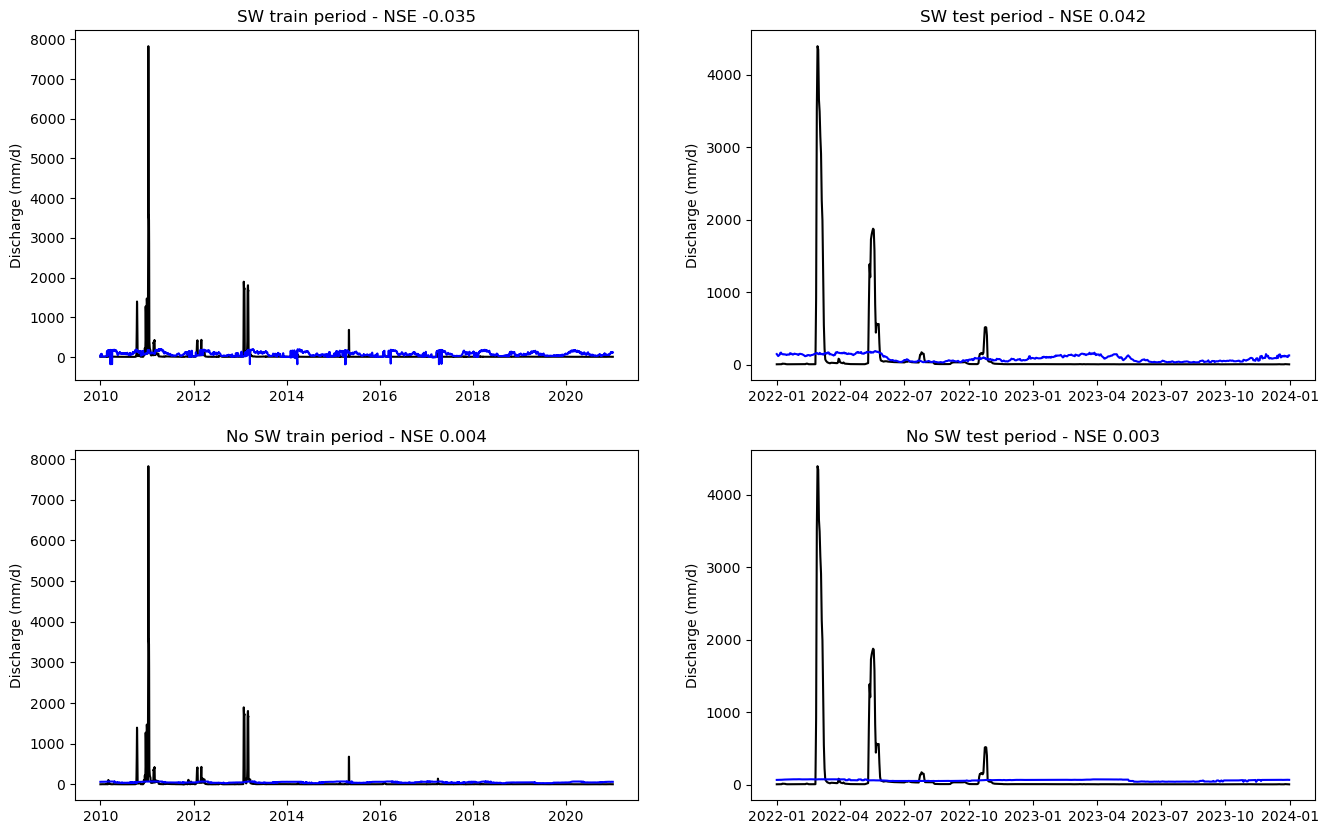

In [11]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[4]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[4]);

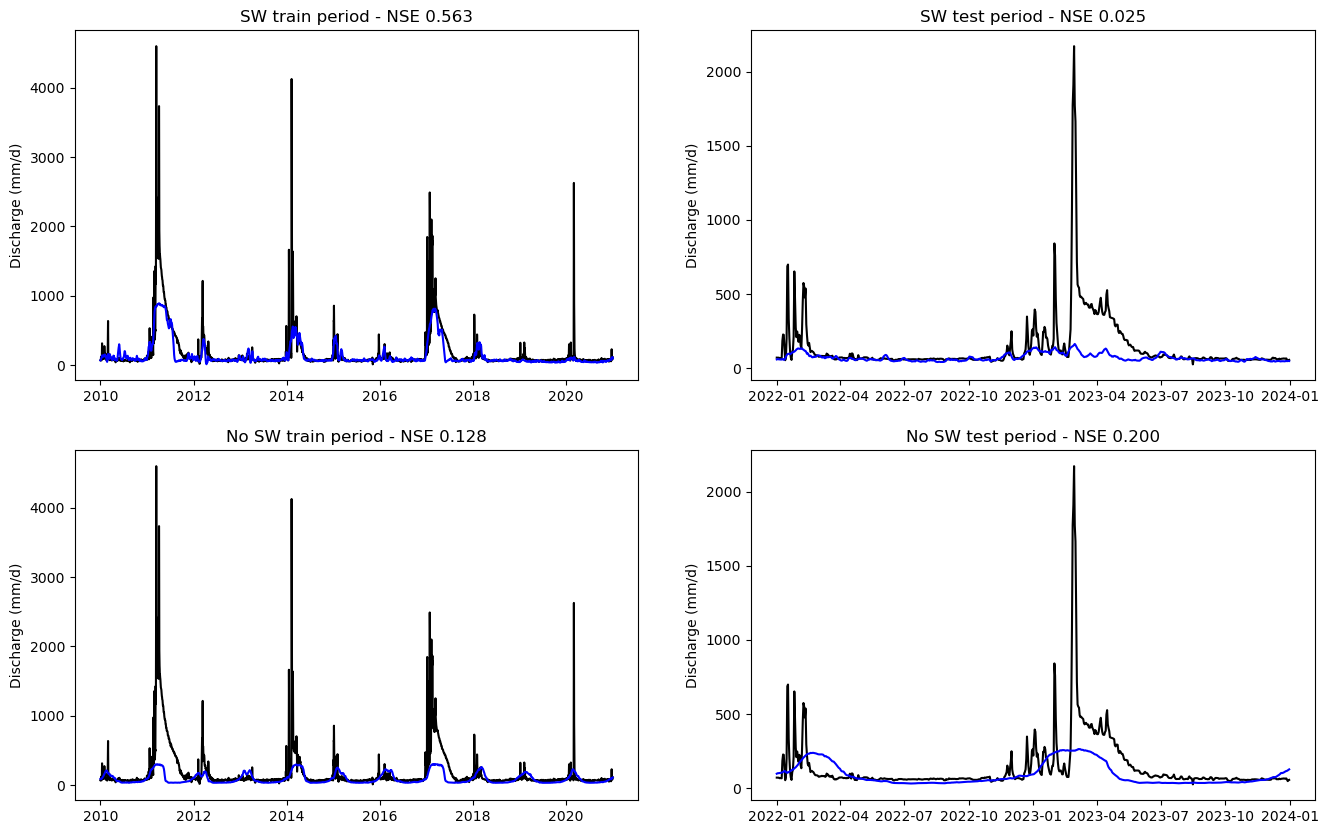

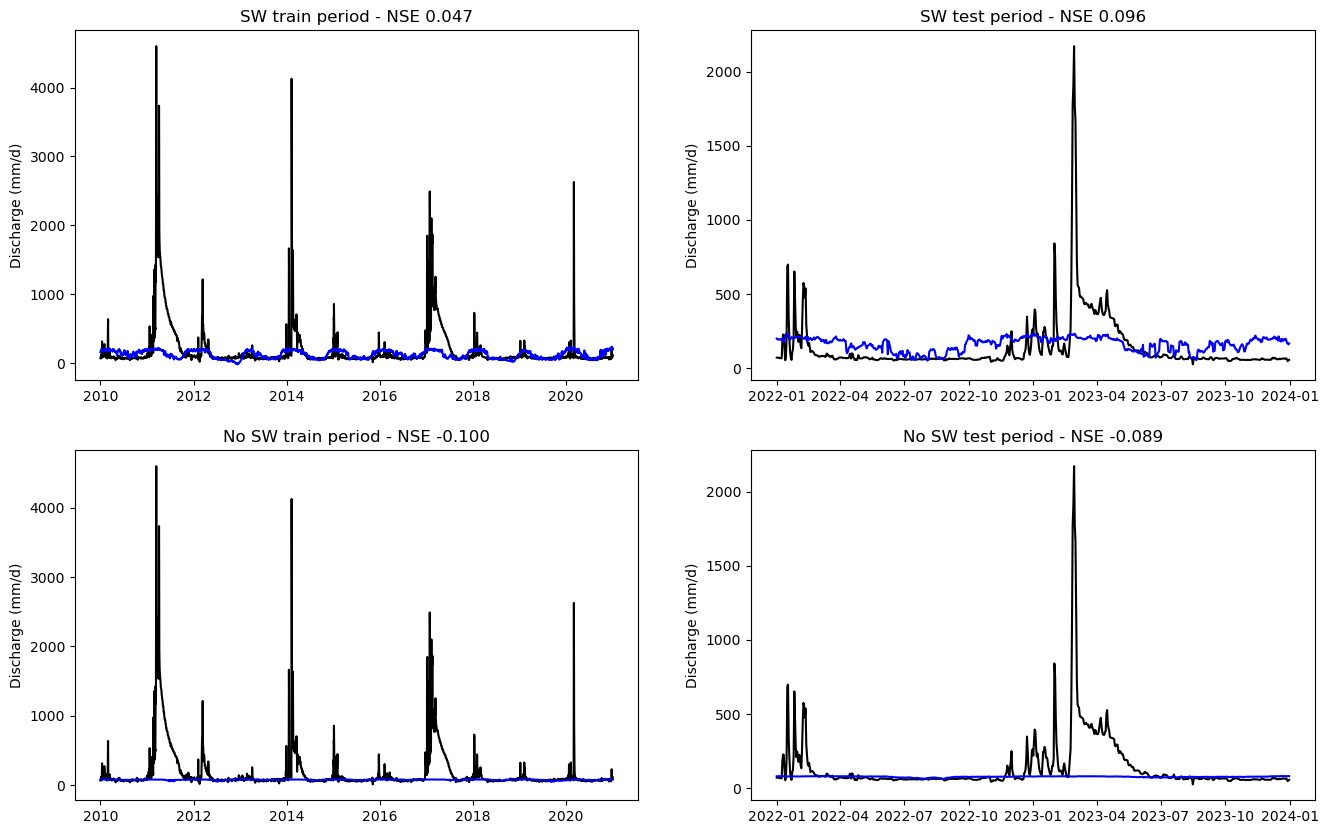

In [12]:
eval_wrapper.quick_basin_plot(*results_tuple_cuda, basin_key = basin_IDs[5]);
eval_wrapper.quick_basin_plot(*results_tuple_ealstm, basin_key = basin_IDs[5]);